In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append(f"./../")

from src.static_graph import StaticGraph
import numpy as np
from scipy.linalg import expm
from qiskit.circuit.library import UnitaryGate
from qiskit.compiler import transpile
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
from sympy import symbols
from sympy import solve, Eq


np.set_printoptions(precision=3, suppress=True)

## 2 Qubits 

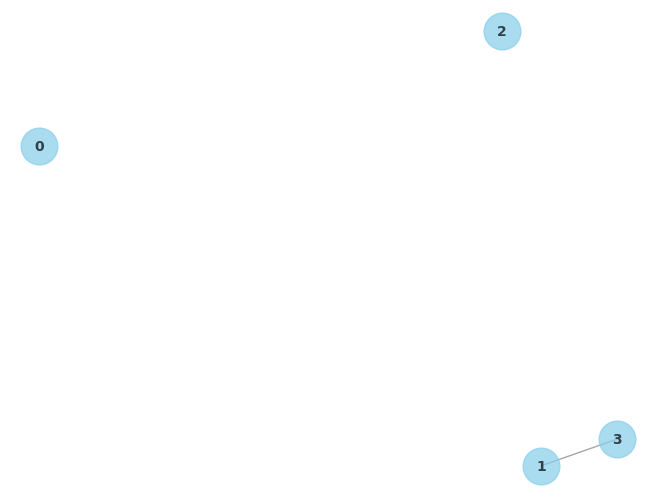

array([[0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 0],
       [0, 1, 0, 0]], dtype=int32)

In [3]:
n_qubits = 2
nodes = set(range(2**n_qubits))
edges = {(1, 3)}
G = StaticGraph(nodes, edges)
G.draw()
G.get_adj_mat()

0.0


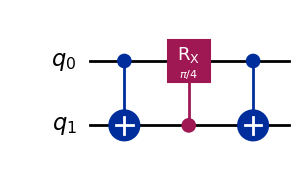

In [4]:
t = np.pi / 8
qc = QuantumCircuit(2)
qc.cx(0, 1)
qc.crx(2 * t, 1, 0)
qc.cx(0, 1)
print(qc.global_phase)
qc.draw("mpl")

In [5]:
def get_qc_statevec(qc, init_state):
    # Convert the circuit to an operator
    op = Operator(qc)
    unitary_matrix = op.data
    unitary_matrix = np.round(unitary_matrix, 2)
    return unitary_matrix @ init_state

In [6]:
def check_qc_for_graph(init_state, qc, G):
    graph_statevec = G.get_statevector()
    qc_statevec = get_qc_statevec(qc, init_state)

    # List to store equations
    equations = []

    # Loop through corresponding elements of vectors and create equations
    for sym1, sym2 in zip(graph_statevec, qc_statevec):
        equation = Eq(sym1, sym2)
        equations.append(equation)

    # Solve the system of equations
    solution = solve(equations, init_state)

    # Count the number of keys with zero values
    zero_count = sum(1 for value in solution.values() if value == 0)

    # Check if the circuit is correct for the particular graph
    if zero_count == 2**n_qubits:
        print("Circuit is wrong for this particular graph")
    else:
        print("Circuit is correct given that", solution)


init_state = np.array([symbols(f"alpha{i}") for i in range(2**n_qubits)])
check_qc_for_graph(init_state, qc, G)

Circuit is correct given that {alpha0: 0.0, alpha1: 0.0, alpha2: 0.0}


## 3 qubits

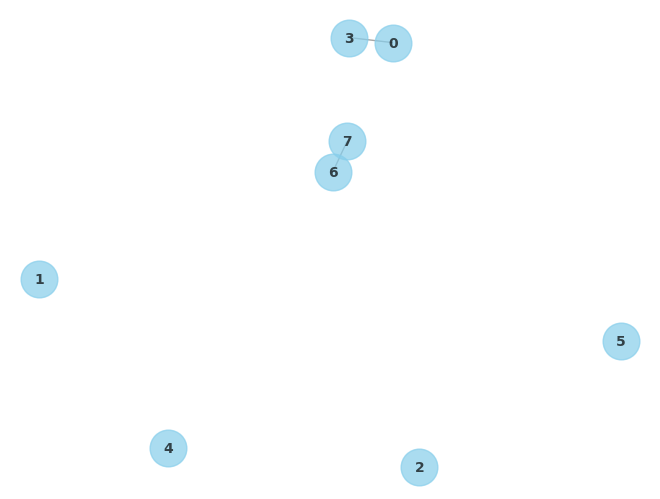

In [7]:
n_qubits = 3
nodes = set(range(2**n_qubits))
edges = {(0, 3), (6, 7)}
G1 = StaticGraph(nodes, edges)
G1.draw()

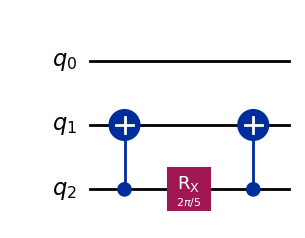

In [8]:
t = np.pi / 5
qc1 = QuantumCircuit(3)
qc1.cx(2, 1)
qc1.rx(2 * t, 2)
qc1.cx(2, 1)
qc1.draw("mpl")

In [9]:
init_state = np.array([symbols(f"alpha{i}") for i in range(2**n_qubits)])
check_qc_for_graph(init_state, qc1, G1)

Circuit is wrong for this particular graph
